# Binary Logistic Regression

This notebook implements Logiestic regression on Tianic survivor dataset 
 

In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

In [112]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor
from scipy.stats import spearmanr

In [161]:
titanic = pd.read_csv("/home/karan/ml/lab/3/data/titanic/Titanic_train.csv")
test  = pd.read_csv("/home/karan/ml/lab/3/data/titanic/Titanic_test.csv")
print(f"Train set -> {titanic.shape}", f"\nTest set -> {test.shape}")

Train set -> (891, 12) 
Test set -> (418, 11)


In [114]:
titanic.head(10)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
5,6,0,3,"Moran, Mr. James",male,NaN,0,0,330877,8.4583,NaN,Q
6,7,0,1,"McCarthy, Mr. Timothy J",male,54.0,0,0,17463,51.8625,E46,S
7,8,0,3,"Palsson, Master. Gosta Leonard",male,2.0,3,1,349909,21.0750,NaN,S
8,9,1,3,"Johnson, Mrs. Oscar W (Elisabeth Vilhelmina Berg)",female,27.0,0,2,347742,11.1333,NaN,S
9,10,1,2,"Nasser, Mrs. Nicholas (Adele Achem)",female,14.0,1,0,237736,30.0708,NaN,C


In [115]:
test.head()

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S
2,894,2,"Myles, Mr. Thomas Francis",male,62.0,0,0,240276,9.6875,NaN,Q
3,895,3,"Wirz, Mr. Albert",male,27.0,0,0,315154,8.6625,NaN,S
4,896,3,"Hirvonen, Mrs. Alexander (Helga E Lindqvist)",female,22.0,1,1,3101298,12.2875,NaN,S


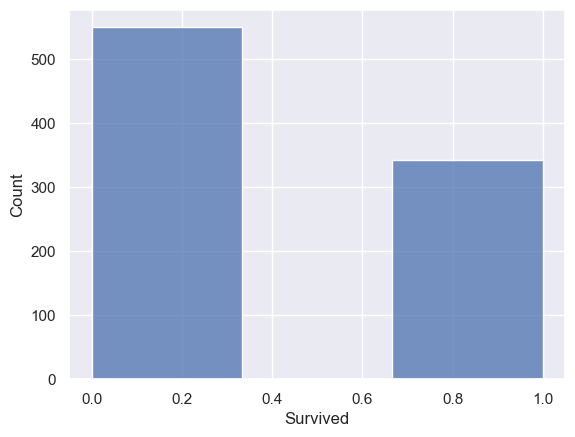

In [116]:
sns.histplot(data=titanic["Survived"], bins=3)
plt.show()

In [117]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [118]:
print("Null values in Train set\n", titanic.isna().sum())
print("\n")
print("Null values in Train set\n", test.isna().sum())


Null values in Train set
 PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64


Null values in Train set
 PassengerId      0
Pclass           0
Name             0
Sex              0
Age             86
SibSp            0
Parch            0
Ticket           0
Fare             1
Cabin          327
Embarked         0
dtype: int64


## Feature Selection

The range of Outcome is  
$$ \mathrm{Survived} \in \{0, 1\} $$

now we need to select what columns (or Features) to use as predictors

In [119]:
# Helper Function for One-Hot Encoding
def one_hot(data, column, dtype, prefix = None):
    dummies = pd.get_dummies(
        data[column],
        prefix= prefix if prefix else column,
        drop_first=True,
        dtype=int
        )
    return pd.concat(
        [data.drop(columns=[column]), dummies],
        axis=1
    )

> We need to drop a column and make it the baseline case, all this to avoid **dummy variable trap** (Perfect Multicollinearity)

In [162]:
y = titanic["Survived"].copy()
X = titanic.drop(columns=["Survived"]).copy() 

#### 1. `PassengerId`
contains unique values , not useful.

In [163]:
X = X.drop(columns=["PassengerId"])
test = test.drop(columns=["PassengerId"])

#### 2. `Pclass`

Represents the Passenger Class 1, 2 and 3.

It is observed that survival rate in class 3 is low comapred to class 1, maybe because of better facilities provided to VIP class passengers.

`Pclass` is a categorical predictor , so we need to encode it properly

In [164]:
# lets see how its distributed
pd.crosstab(titanic["Pclass"], titanic["Survived"])

Survived,0,1
Pclass,,
1,80,136
2,97,87
3,372,119


In [165]:
pd.crosstab(
    titanic["Pclass"],
    titanic["Survived"],
    # divide value by sum of that row
    normalize="index" 
)

Survived,0,1
Pclass,,
1,0.370370,0.629630
2,0.527174,0.472826
3,0.757637,0.242363


Survival rate in lower class is very less 😥

In [166]:
X = one_hot(X, "Pclass", dtype=int)
test = one_hot(test, "Pclass", dtype=int)

In [167]:
X

,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Pclass_2,Pclass_3
0,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S,0,1
1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C,0,0
2,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1
3,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S,0,0
4,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S,0,1
...,...,...,...,...,...,...,...,...,...,...,...
886,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S,1,0
887,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S,0,0
888,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S,0,1
889,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C,0,0


#### 3. `Name`

useless, drop it

In [168]:
X = X.drop(columns=["Name"])
test = test.drop(columns=["Name"])

#### 4. `Sex`

Does Gender affects the survival of passenger ?

In [169]:
pd.crosstab(titanic["Sex"], titanic["Survived"], normalize="index")


Survived,0,1
Sex,,
female,0.257962,0.742038
male,0.811092,0.188908


In [170]:
X = one_hot(X, "Sex", dtype=int)
test = one_hot(test, "Sex", dtype=int)

In [171]:
X

,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Pclass_2,Pclass_3,Sex_male
0,22.0,1,0,A/5 21171,7.2500,NaN,S,0,1,1
1,38.0,1,0,PC 17599,71.2833,C85,C,0,0,0
2,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1,0
3,35.0,1,0,113803,53.1000,C123,S,0,0,0
4,35.0,0,0,373450,8.0500,NaN,S,0,1,1
...,...,...,...,...,...,...,...,...,...,...
886,27.0,0,0,211536,13.0000,NaN,S,1,0,1
887,19.0,0,0,112053,30.0000,B42,S,0,0,0
888,NaN,1,2,W./C. 6607,23.4500,NaN,S,0,1,0
889,26.0,0,0,111369,30.0000,C148,C,0,0,1


#### 5. `Age`

does age affect survival rate ? seems like it does , maybe during rescue childerns were given priority over adults.

In [172]:
X["Age"].describe()

count    714.000000
mean      29.699118
std       14.526497
min        0.420000
25%       20.125000
50%       28.000000
75%       38.000000
max       80.000000
Name: Age, dtype: float64

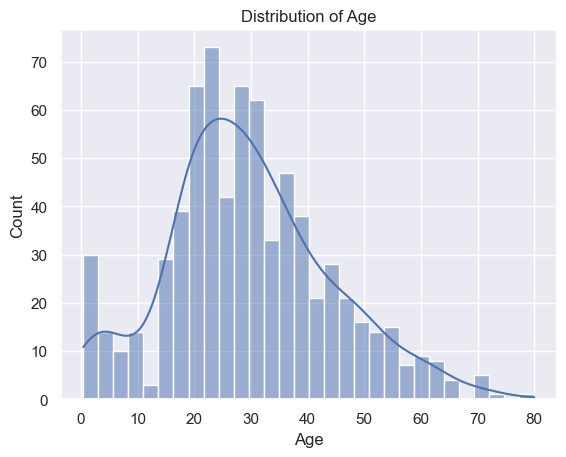

In [173]:
sns.histplot(X["Age"], bins=30, kde=True)
plt.title("Distribution of Age")
plt.show()

seems like most of the passengers were around age 18 ~ 40 , now we need to see age and survival relation. Since `Age` is continuous , we need to break it into categories and then analyse survival rate for each category. 

In [174]:
# Categorize AGE into bins
age_cat = pd.cut(
    X["Age"],
    bins=[0, 13, 20, 35, 60, 100],
    labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"]
)
age_cat = age_cat.cat.add_categories("Unknown").fillna("Unknown")

# include in the df
def age_group(age):
    if pd.isna(age):
        return "Unknown"
    elif age < 13:
        return "Child"
    elif age < 20:
        return "Teen"
    elif age < 35:
        return "YoungAdult"
    elif age < 60:
        return "Adult"
    else:
        return "Senior"

X["AgeGroup"] = X["Age"].apply(age_group)
test["AgeGroup"] = test["Age"].apply(age_group)

X = X.drop(columns=["Age"])
test = test.drop(columns=["Age"])

In [175]:
# Create a frequency table wrt survival
pd.crosstab(
    X["AgeGroup"],
    y,
    normalize="index"
)

Survived,0,1
AgeGroup,,
Adult,0.583732,0.416268
Child,0.420290,0.579710
Senior,0.730769,0.269231
Teen,0.589474,0.410526
Unknown,0.706215,0.293785
YoungAdult,0.628571,0.371429


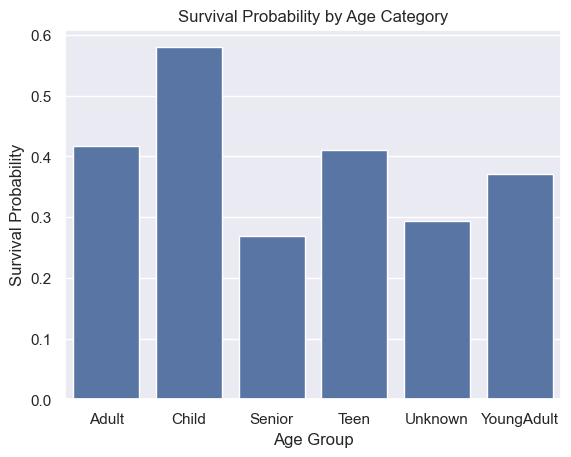

In [176]:
# redundant plot tbh

plot_df = X[["AgeGroup"]].join(y.rename("Survived"))

survival_by_age = (
    plot_df
    .groupby("AgeGroup")["Survived"]
    .mean()
)

survival_by_age = plot_df.groupby("AgeGroup")["Survived"].mean()

sns.barplot(
    x=survival_by_age.index,
    y=survival_by_age.values
)

plt.ylabel("Survival Probability")
plt.xlabel("Age Group")
plt.title("Survival Probability by Age Category")
plt.show()


now we need to properly enccode all these age groups into our predictors matrix, hmmmmmmmmmmmmmm, lets make the **Adult** baseline for this purpose

In [177]:
test.head()

,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Pclass_2,Pclass_3,Sex_male,AgeGroup
0,0,0,330911,7.8292,NaN,Q,0,1,1,YoungAdult
1,1,0,363272,7.0000,NaN,S,0,1,0,Adult
2,0,0,240276,9.6875,NaN,Q,1,0,1,Senior
3,0,0,315154,8.6625,NaN,S,0,1,1,YoungAdult
4,1,1,3101298,12.2875,NaN,S,0,1,0,YoungAdult


In [178]:
X = one_hot(X, "AgeGroup", dtype=int, prefix="Age")
test = one_hot(test, "AgeGroup", dtype=int, prefix="Age")

In [179]:
X.head()

,SibSp,Parch,Ticket,Fare,Cabin,Embarked,Pclass_2,Pclass_3,Sex_male,Age_Child,Age_Senior,Age_Teen,Age_Unknown,Age_YoungAdult
0,1,0,A/5 21171,7.2500,NaN,S,0,1,1,0,0,0,0,1
1,1,0,PC 17599,71.2833,C85,C,0,0,0,0,0,0,0,0
2,0,0,STON/O2. 3101282,7.9250,NaN,S,0,1,0,0,0,0,0,1
3,1,0,113803,53.1000,C123,S,0,0,0,0,0,0,0,0
4,0,0,373450,8.0500,NaN,S,0,1,1,0,0,0,0,0


#### 6. `SibSp`

Siblings/Spouse , so does having a family increases your survival chances in Titanic ? lets see

In [180]:
X["SibSp"].value_counts().sort_index()

SibSp
0    608
1    209
2     28
3     16
4     18
5      5
8      7
Name: count, dtype: int64

hmmmmm, so 0 means the person is traveling alone, 1 mean with some another person (sibling/spouse), >2 means with more persons (multiple spouse ???)

lets see the survival rate for these family sizes

In [181]:
pd.crosstab(
    X["SibSp"],
    y,
    normalize="index"
)

Survived,0,1
SibSp,,
0,0.654605,0.345395
1,0.464115,0.535885
2,0.535714,0.464286
3,0.750000,0.250000
4,0.833333,0.166667
5,1.000000,0.000000
8,1.000000,0.000000


> dont travel in large gropus, not on Titanic 🥺

lets encode these different family sizes, we will use three categories (Alone, SamllFam, LargeFam) 

In [182]:
def get_famCat(x):
    if x == 0:
        return "Alone"
    elif x <= 2:
        return "Small"
    else:
        return "Large"

X["SibSpGroup"] = X["SibSp"].apply(get_famCat)
test["SibSpGroup"] = test["SibSp"].apply(get_famCat)

X = X.drop(columns=["SibSp"])
test = test.drop(columns=["SibSp"])

In [183]:
# cross checking if label encoding is correct
pd.crosstab(
    X["SibSpGroup"],
    y,
    normalize="index"
)


Survived,0,1
SibSpGroup,,
Alone,0.654605,0.345395
Large,0.847826,0.152174
Small,0.472574,0.527426


In [184]:
X = one_hot(X, "SibSpGroup", dtype=int, prefix="SibSp")
test = one_hot(test, "SibSpGroup", dtype=int, prefix="SibSp")

In [185]:
X

,Parch,Ticket,Fare,Cabin,Embarked,Pclass_2,Pclass_3,Sex_male,Age_Child,Age_Senior,Age_Teen,Age_Unknown,Age_YoungAdult,SibSp_Large,SibSp_Small
0,0,A/5 21171,7.2500,NaN,S,0,1,1,0,0,0,0,1,0,1
1,0,PC 17599,71.2833,C85,C,0,0,0,0,0,0,0,0,0,1
2,0,STON/O2. 3101282,7.9250,NaN,S,0,1,0,0,0,0,0,1,0,0
3,0,113803,53.1000,C123,S,0,0,0,0,0,0,0,0,0,1
4,0,373450,8.0500,NaN,S,0,1,1,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
886,0,211536,13.0000,NaN,S,1,0,1,0,0,0,0,1,0,0
887,0,112053,30.0000,B42,S,0,0,0,0,0,1,0,0,0,0
888,2,W./C. 6607,23.4500,NaN,S,0,1,0,0,0,0,1,0,0,1
889,0,111369,30.0000,C148,C,0,0,1,0,0,0,0,1,0,0


#### 7. `Parch`

Parent/Children , does having parent/Childrens would increase your survival chances ? 

this is kinda same as the Siblings/Spouse, also its possible to find some kind of collinearity between these features. 

we need to use the original value for both columns  

In [186]:
# setting up the predictor's matrix
x = sm.add_constant(titanic[["SibSp", "Parch"]])

vif = pd.DataFrame()
vif["feature"] = x.columns
vif["VIF"] = [variance_inflation_factor(x, i) for i in range(x.shape[1])] 
vif

,feature,VIF
0,const,1.317747
1,SibSp,1.207861
2,Parch,1.207861


not corelated ????? 🙀

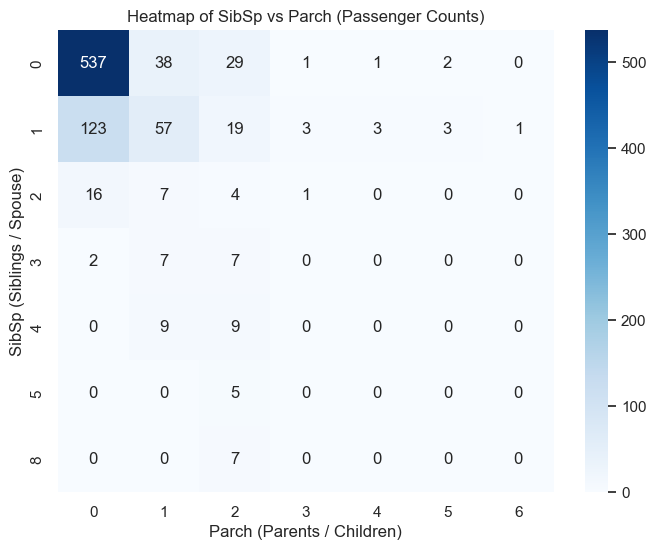

In [187]:
ct = pd.crosstab(titanic["SibSp"], titanic["Parch"])

# heatmap would help, right?
plt.figure(figsize=(8, 6))
sns.heatmap(
    ct,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Parch (Parents / Children)")
plt.ylabel("SibSp (Siblings / Spouse)")
plt.title("Heatmap of SibSp vs Parch (Passenger Counts)")
plt.show()

damnn , looks like there isnt much corelation , we need to encode it also 🥺

In [188]:
X = X.drop(columns=["Parch"])
test = test.drop(columns=["Parch"])

#### 8. `Ticket`

dropppppp it , not usefull at all

In [189]:
X = X.drop(columns=["Ticket"])
test = test.drop(columns=["Ticket"])

#### 9. `Fare`

fare given by corresponding passenger, 

I feel like this would be highly corelated with the `Pclass`, since class 1 tickets would be expensive than lower class tickets


In [190]:
corr, p_value = spearmanr(titanic["Pclass"], titanic["Fare"])
print(corr)

-0.6880316726256098


strong correlation , have to drop this feature

In [191]:
X = X.drop(columns=["Fare"])
test = test.drop(columns=["Fare"])

#### 10. `Cabin`

again drop it.

In [192]:
X = X.drop(columns=["Cabin"])
test = test.drop(columns=["Cabin"])

In [193]:
test

,Embarked,Pclass_2,Pclass_3,Sex_male,Age_Child,Age_Senior,Age_Teen,Age_Unknown,Age_YoungAdult,SibSp_Large,SibSp_Small
0,Q,0,1,1,0,0,0,0,1,0,0
1,S,0,1,0,0,0,0,0,0,0,1
2,Q,1,0,1,0,1,0,0,0,0,0
3,S,0,1,1,0,0,0,0,1,0,0
4,S,0,1,0,0,0,0,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...
413,S,0,1,1,0,0,0,1,0,0,0
414,C,0,0,0,0,0,0,0,0,0,0
415,S,0,1,1,0,0,0,0,0,0,0
416,S,0,1,1,0,0,0,1,0,0,0


#### 11. `Embarked`

boarding port of passengers. would this help determin the survival of a passenger ? lets see

In [194]:
X["Embarked"].value_counts(dropna=False)

Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

there are only 2 none values, we could just drop them, but better think would ne to fill them with mode of the distribution , which is Port `S`

In [195]:
X["Embarked"] = X["Embarked"].fillna("S")

In [196]:
X = one_hot(X, "Embarked", dtype=int)
test = one_hot(test, "Embarked", dtype=int)

In [197]:
X

,Pclass_2,Pclass_3,Sex_male,Age_Child,Age_Senior,Age_Teen,Age_Unknown,Age_YoungAdult,SibSp_Large,SibSp_Small,Embarked_Q,Embarked_S
0,0,1,1,0,0,0,0,1,0,1,0,1
1,0,0,0,0,0,0,0,0,0,1,0,0
2,0,1,0,0,0,0,0,1,0,0,0,1
3,0,0,0,0,0,0,0,0,0,1,0,1
4,0,1,1,0,0,0,0,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
886,1,0,1,0,0,0,0,1,0,0,0,1
887,0,0,0,0,0,1,0,0,0,0,0,1
888,0,1,0,0,0,0,1,0,0,1,0,1
889,0,0,1,0,0,0,0,1,0,0,0,0


In [198]:
test

,Pclass_2,Pclass_3,Sex_male,Age_Child,Age_Senior,Age_Teen,Age_Unknown,Age_YoungAdult,SibSp_Large,SibSp_Small,Embarked_Q,Embarked_S
0,0,1,1,0,0,0,0,1,0,0,1,0
1,0,1,0,0,0,0,0,0,0,1,0,1
2,1,0,1,0,1,0,0,0,0,0,1,0
3,0,1,1,0,0,0,0,1,0,0,0,1
4,0,1,0,0,0,0,0,1,0,1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...
413,0,1,1,0,0,0,1,0,0,0,0,1
414,0,0,0,0,0,0,0,0,0,0,0,0
415,0,1,1,0,0,0,0,0,0,0,0,1
416,0,1,1,0,0,0,1,0,0,0,0,1


## Model Fitting
The sigmoid function is a smooth function that maps andy real number 
$z ∈ R$ to a value strictly between 0 and 1

$$
\boxed{
\sigma(z) = \frac{1}{1 + e^{-z}},
\quad
\sigma : \mathbb{R} \rightarrow (0,1)
}
$$

In [157]:
def sigmoid(z):
    """
    Parameters:
        z (float or numpy.ndarray): The input value(s) for which to compute the sigmoid.

    Returns:
        float or numpy.ndarray: The sigmoid of the input value(s).
    """
    return 1/(1 + np.exp(-z))

## Logistic Regression Theory


Here is some theory on Binary Logistic regression. It models the probability that a given input belongs to a particular class. The logistic regression model function is represented as:

$$
f_{\mathbf{w}, b}(\mathbf{x}) = \sigma(\mathbf{w} \cdot \mathbf{x} + b) = z
$$

In this equation, $  f_{\mathbf{w}, b}(\mathbf{x}) $ represents the predicted probability, $ \mathbf{w} $ is the weight vector, $ b $ is the bias term, $ \mathbf{x} $ is the input feature vector, and $ g(z) $ is the sigmoid function:

$$
\sigma(z) = \frac{1}{1 + e^{-z}}
$$

so , the model predicts membership(or probability) of each observation in class 1, 
$$
\mathrm{Pr}(Y = 1 | X) = \sigma(z)
$$

once we have these prediction probability, we can set a threshold $\mathrm{t} = 0.5$, such that,

$$
p(x_i) \ge t \implies x_i \in \mathrm{1} , \forall i
$$

### Model Training

To train a logistic regression model, we aim to find the best values for the parameters $ (\mathbf{w}, b) $ that best fit our dataset and provide accurate class probabilities.

#### 1. Forward Pass

The forward pass computes the linear combination of input features $ \mathbf{x} $ with the weight vector $ \mathbf{w} $ and the bias term $ b $, and then applies the sigmoid function:

$$
Z = \mathbf{x} \cdot \mathbf{w} + b
$$

$$
A = \sigma(Z)
$$

#### 2. Cost Function

The cost function measures the error between the predicted probabilities and the true labels. In logistic regression, we use the binary cross-entropy loss function.

Specifically, we minimize the empirical risk of the Bernoulli model that we assumed , and we take mean/avg over the dataset as the unbiased estimator of population risk , since we dont know the underlying model.

$$
J(\mathbf{w}, b)
=
-\frac{1}{n}
\sum_{i=0}^{m-1}
\left[
y_i \log\left(f_{\mathbf{w}, b}(\mathbf{x}_i)\right)
+
(1 - y_i)\log\left(1 - f_{\mathbf{w}, b}(\mathbf{x}_i)\right)
\right]
$$

Here, $ n $ is the number of samples, $ y_i $ is the true label of sample $ i $, and $ f_{\mathbf{w}, b}(\mathbf{x}_i) $ is the predicted probability of sample $ i $ belonging to the positive class.

#### 3. Backward Pass (Gradient Computation)

The backward pass calculates the gradients of the cost function with respect to the parameters $ (\mathbf{w}, b) $:

$$
\frac{\partial J(\mathbf{w}, b)}{\partial b}
=
\frac{1}{n}
\sum_{i=0}^{n-1}
\left(
f_{\mathbf{w}, b}(\mathbf{x}_i) - y_i
\right)
$$

$$
\frac{\partial J(\mathbf{w}, b)}{\partial \mathbf{w}}
=
\frac{1}{n}
\sum_{i=0}^{n-1}
\left(
f_{\mathbf{w}, b}(\mathbf{x}_i) - y_i
\right)\mathbf{x}_i
$$

### Training Process

The training process involves iteratively updating the weight vector $ \mathbf{w} $ and bias term $ b $ to minimize the cost function using gradient descent. The update equations are:

$$
\mathbf{w} \leftarrow \mathbf{w} - \eta \frac{\partial J}{\partial \mathbf{w}}
$$

$$
b \leftarrow b - \eta \frac{\partial J}{\partial b}
$$

Here, $ \eta $ represents the learning rate.


there is a whole lot interesting theory on the learning rate $\eta$ on its own, like the range of $\eta$ for which Gradient Descent converges and does not explode, which is given by,

$$
0 \lt \eta \lt \frac{2}{L}
$$

where $L = \lambda_{max}$ is the Lipschitz constant for cost function of Logistic regression, ($\lambda_{max}$ is the largest eigenvalue of the hessian of log-loss surface)

In [158]:
class LogisticRegression:

    """
    Logistic Regression model.

    Parameters:
        learning_rate (float): Learning rate for the model.

    Methods:
        initialize_parameter(): Initializes the parameters of the model.
        sigmoid(z): Computes the sigmoid activation function for given input z.
        forward(X): Computes forward propagation for given input X.
        compute_cost(predictions): Computes the cost function for given predictions.
        compute_gradient(predictions): Computes the gradients for the model using given predictions.
        fit(X, y, iterations, plot_cost): Trains the model on given input X and labels y for specified iterations.
        predict(X): Predicts the labels for given input X.
    """

    def __init__(self, learning_rate=0.01):
        self.rng = np.random.default_rng(seed=42)
        self.learning_rate = learning_rate

    def init_parameters(self):
        self.W = np.zeros(self.X.shape[1])
        self.b = 0.0

    def forward(self, X):
        """
        Computes forward propagation for given input X.
        Parameters:
            X (numpy.ndarray): Input array.
        Returns:
            numpy.ndarray: Output array.
        """

        Z = X @ self.W + self.b
        return sigmoid(Z)
    
    def cost(self, predictions):
        """
        Computes the Binary Cross entropy (log-loss) function for given predictions.

        Parameters:
            predictions (numpy.ndarray): Predictions of the model.

        Returns:
            float: Cost of the model.
        """

        n = self.X.shape[0] # number of observations
        # we are adding small value epsilon = 1e-8 to avoid log(0) = -inf
        cost = np.sum((-np.log(predictions + 1e-8)*self.y) + (-np.log(1 - predictions + 1e-8))*(1 - self.y))
        cost = cost/n  # unbiased estimator of empirical risk

        return cost
    

    def gradient(self, predictions):
        """
        Computes the gradients for the model using given predictions.

        Parameters:
            predictions (numpy.ndarray): Predictions of the model.
        """
        # get training shape
        n = self.X.shape[0]

        # compute gradients
        self.dW = self.X.T @ (predictions - self.y)
        self.db = np.sum(np.subtract(predictions, self.y))

        # scale gradients
        self.dW = self.dW * 1 / n
        self.db = self.db * 1 / n


    def fit(self, X, y, iterations, plot_cost=True):
        """
        Trains the model on given input X and labels y for specified iterations.

        Parameters:
            X (numpy.ndarray): Input features array of shape (n_samples, n )
            y (numpy.ndarray): Labels array of shape (n_samples, 1)
            iterations (int): Number of iterations for training.
            plot_cost (bool): Whether to plot cost over iterations or not.

        Returns:
            None.
        """
        self.X = X
        self.y = y

        self.init_parameters()

        costs = []
        for i in range(iterations):
            # forward propagation
            predictions = self.forward(self.X)

            # calculate cost
            cost = self.cost(predictions)
            costs.append(cost)

            # gradient values
            self.gradient(predictions)

            # update rules
            self.W = self.W - self.learning_rate * self.dW
            self.b = self.b - self.learning_rate * self.db

            # print cost every 100 iterations
            if i % 10000 == 0:
                print(f"Cost after iteration {i}: {cost}")

        if plot_cost:
            sns.set_theme(style="darkgrid")
            plt.figure(figsize=(8, 5))
            plt.plot(costs)
            plt.xlabel("Iterations")
            plt.ylabel("Cost")
            plt.title("Cost vs Iteration")
            plt.show()

    
    def predict(self, X):
        """
        Predicts the labels for given input X.

        Parameters:
            X (numpy.ndarray): Input features array.

        Returns:
            numpy.ndarray: Predicted labels.
        """
        predictions = self.forward(X)
        return np.round(predictions)
    

    def save_model(self, filename=None):
        """
        Save the trained model to a file using pickle.

        Parameters:
            filename (str): The name of the file to save the model to.
        """
        model_data = {
            'learning_rate': self.learning_rate,
            'W': self.W,
            'b': self.b
        }

        with open(filename, 'wb') as file:
            pickle.dump(model_data, file)
        

    @classmethod
    def load_model(cls, filename):
        """
        Load a trained model from a file using pickle.

        Parameters:
            filename (str): The name of the file to load the model from.

        Returns:
            LogisticRegression: An instance of the LogisticRegression class with loaded parameters.
        """
        with open(filename, 'rb') as file:
            model_data = pickle.load(file)

        # Create a new instance of the class and initialize it with the loaded parameters
        loaded_model = cls(model_data['learning_rate'])
        loaded_model.W = model_data['W']
        loaded_model.b = model_data['b']

        return loaded_model
        


Cost after iteration 0: 0.6931471605599454
Cost after iteration 10000: 0.4459352830769072
Cost after iteration 20000: 0.43482781451265456
Cost after iteration 30000: 0.43160199018703044
Cost after iteration 40000: 0.4303794216222622
Cost after iteration 50000: 0.42984567093583936
Cost after iteration 60000: 0.4295933289530179
Cost after iteration 70000: 0.4294683035102817
Cost after iteration 80000: 0.42940454465310807
Cost after iteration 90000: 0.4293714225856882


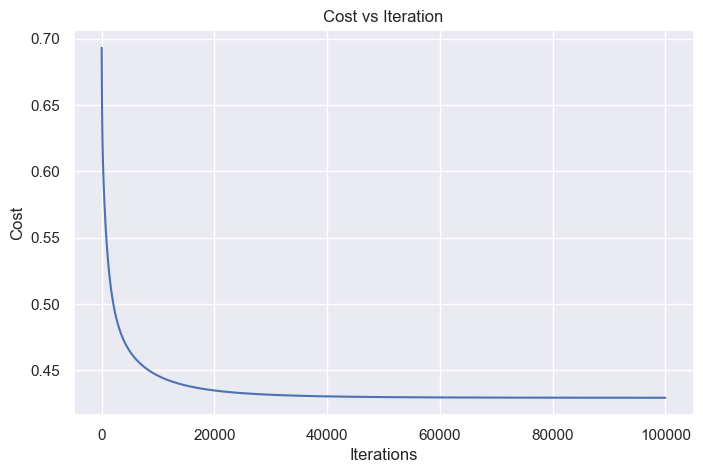

In [89]:
lg = LogisticRegression()
lg.fit(X, y, 100000)

## Model Evalvuation

In classification tasks, it's crucial to evaluate the performance of your model. There are several metrics that can help you understand how well your model is performing. Here are four commonly used classification metrics:

### 1. Accuracy

**Formula:**

$$
\text{Accuracy} = \frac{\text{Number of Correct Predictions}}{\text{Total Number of Predictions}}
$$

**Description:**

- **Accuracy** measures the proportion of correctly predicted instances out of all instances in a classification model.
- It is a widely used metric for evaluating classification performance.

**Interpretation:**

- A higher accuracy value indicates a better classification model.
- However, accuracy alone may not provide a complete picture, especially in imbalanced datasets.



### 2. Precision

**Formula:**

$$
\text{Precision} = \frac{\text{True Positives}}{\text{True Positives + False Positives}}
$$

**Description:**

- **Precision** measures the proportion of true positive predictions out of all positive predictions made by the model.
- It is a useful metric when the cost of false positives is high.

**Interpretation:**

- Higher precision means the model makes fewer false positive predictions.



### 3. Recall (Sensitivity)

**Formula:**

$$
\text{Recall (Sensitivity)} = \frac{\text{True Positives}}{\text{True Positives + False Negatives}}
$$

**Description:**

- **Recall**, also known as sensitivity or true positive rate, measures the proportion of true positive predictions out of all actual positive instances in the dataset.
- It is a valuable metric when it's essential to capture all positive instances.

**Interpretation:**

- Higher recall means the model captures more of the actual positive instances.



### 4. F1-Score

**Formula:**

$$
\text{F1-Score} = 2 \times \frac{\text{Precision} \times \text{Recall}}{\text{Precision + Recall}}
$$

**Description:**

- The **F1-Score** is the harmonic mean of precision and recall.
- It provides a balance between precision and recall, making it a suitable metric when there is a trade-off between false positives and false negatives.

**Interpretation:**

- A higher F1-Score indicates a model that achieves a balance between precision and recall.


In [94]:
class Evaluation:

    @staticmethod
    def accuracy(y_true, y_pred):
        
        return (np.sum(y_true == y_pred)/ len(y_true))
    
    @staticmethod
    def precision(y_true, y_pred):
        true_positives = np.sum((y_true == 1) & (y_pred == 1))
        false_positives = np.sum((y_true == 0) & (y_pred == 1))
        return true_positives / (true_positives + false_positives)
    
    @staticmethod
    def recall(y_true, y_pred):
        true_positives = np.sum((y_true == 1) & (y_pred == 1))
        false_negatives = np.sum((y_true == 1) & (y_pred == 0))
        return true_positives / (true_positives + false_negatives)
    
    @staticmethod
    def f1(y_true, y_pred):
        precision_value = Evaluation.precision(y_true, y_pred)
        recall_value = Evaluation.recall(y_true, y_pred)
        return 2 * (precision_value * recall_value) / (precision_value + recall_value)

In [91]:
test.isna().sum()

Pclass_2          0
Pclass_3          0
Sex_male          0
Age_Child         0
Age_Senior        0
Age_Teen          0
Age_Unknown       0
Age_YoungAdult    0
Age_Child         0
Age_Senior        0
Age_Teen          0
Age_Unknown       0
Age_YoungAdult    0
SibSp_Large       0
SibSp_Small       0
Embarked_Q        0
Embarked_S        0
dtype: int64

In [109]:
y_pred = lg.predict(test)
y_pred

0      0.0
1      0.0
2      0.0
3      0.0
4      1.0
      ... 
413    0.0
414    1.0
415    0.0
416    0.0
417    0.0
Length: 418, dtype: float64

### Submissions

now that we have our predictions, lets submit them on Kaggle and see how well our model performs, achieves around `0.77` public on Kaggle, its pretty low, but hey we only used basic Logistic regression with plain GD (implemented from scratch), we havent even used regularization yet. 

so cheer up, its a good score for a begginer learner

In [199]:
submission = pd.DataFrame({
    "PassengerId": pd.read_csv("/home/karan/ml/lab/3/data/titanic/Titanic_test.csv")["PassengerId"],
    "Survived": y_pred.astype(int)
})

submission.to_csv("submission.csv", index=False)
